<a href="https://colab.research.google.com/github/snehaparepalli14/lunar_lander/blob/main/Copy_of_Team_22_Q_learning_DQN_DDQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DRL Assignment II
## Robust Reinforcement Learning under Stochastic Action Failure

**Course:** Deep Reinforcement Learning (S2-25_AIMLCZG512)

**Group 22**

### Group Information & Contribution Details

| Name                         | BITS ID     | Contribution Percentage |
| :-----------------------------| :------------| :-----------------------:|
| Bodapatla Yogeshwar Reddy    | 2025AB05052 | 100 %                   |
| Dalvi Namita Vishnu Veena    | 2025AB05263 | 100 %                   |
| Nischal R                    | 2025AA05180 | 100 %                   |
| Pandyaram Vamsi Muralidhar   | 2025AA05660 | 100 %                   |
| Parepalli N V L S Sneha Sree | 2025AB05137 | 100 %                   |



In [2]:
from __future__ import annotations

import argparse
import csv
import json
import random
from collections import deque
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Deque, Literal

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

!pip install swig "gymnasium[box2d]" -q


print(f'PyTorch {torch.__version__} | Gymnasium {gym.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.9 MB/s eta 0:00:00
PyTorch 2.11.0+cu128 | Gymnasium 1.3.0


## Section 1 — Custom Environment Wrapper

The standard `LunarLander-v3` environment is extended with a wrapper that simulates real-world actuator unreliability. Three modifications are applied on every environment step:

- **Stochastic action failure (15%):** Any thruster command (actions 1, 2, or 3) has a 15% chance of silently misfiring — the engine does nothing (action 0) instead. The agent receives no indication that this occurred.
- **Fuel penalty (−0.3):** A fixed cost is subtracted for every thruster action the agent *requests*, regardless of whether the engine actually fires. This discourages wasteful thruster usage.
- **Safe-landing bonus (+50):** A one-time bonus is awarded at the end of an episode when both landing legs make contact, the lander is moving slowly (|vx|, |vy| < 0.10), and the body is nearly level (|angle| < 0.10).

> **Note:** The failure mechanism is fully hidden from the agent. The `info` dictionary is passed through unchanged, so the agent must learn a robust policy without knowing when its actions are ignored.


In [4]:
@dataclass
class FailureStatistics:
    """Counters used to verify the wrapper without exposing data to the agent."""
    attempted_thruster_actions: int = 0
    failed_thruster_actions: int = 0
    attempted_fuel_penalty: float = 0.0
    safe_landing_bonus_count: int = 0

    @property
    def observed_failure_rate(self) -> float:
        """Return the fraction of attempted thruster actions that misfired."""
        if self.attempted_thruster_actions == 0:
            return 0.0
        return self.failed_thruster_actions / self.attempted_thruster_actions


class StochasticFailureLunarLander(gym.Wrapper):
    """Apply intermittent engine failure and modified rewards to LunarLander.

    A requested thruster action (1, 2, or 3) has a 15% probability of becoming
    action 0. The fuel penalty is based on the action requested by the agent,
    even if that action subsequently fails.
    """
    FAILURE_PROBABILITY = 0.15
    FUEL_PENALTY = 0.3
    SAFE_LANDING_BONUS = 50.0
    VELOCITY_LIMIT = 0.10
    ANGLE_LIMIT = 0.10

    def __init__(self, env: gym.Env):
        """Wrap an existing LunarLander-v3 environment."""
        super().__init__(env)
        self.statistics = FailureStatistics()

    def reset_statistics(self) -> None:
        """Clear verification counters before a new experiment."""
        self.statistics = FailureStatistics()

    def _sample_executed_action(self, selected_action: int) -> int:
        """Return the action the base environment will execute."""
        if selected_action == 0:
            return 0
        self.statistics.attempted_thruster_actions += 1
        if self.np_random.random() < self.FAILURE_PROBABILITY:
            self.statistics.failed_thruster_actions += 1
            return 0
        return selected_action

    def _safe_landing(self, observation: np.ndarray, terminated: bool, truncated: bool) -> bool:
        """Return whether the final state meets every safe-landing condition."""
        return bool(
            terminated
            and not truncated
            and observation[6] == 1
            and observation[7] == 1
            and abs(observation[2]) < self.VELOCITY_LIMIT
            and abs(observation[3]) < self.VELOCITY_LIMIT
            and abs(observation[4]) < self.ANGLE_LIMIT
        )

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        """Execute a possibly failed action and return the specified reward."""
        selected_action = int(action)
        if not self.action_space.contains(selected_action):
            raise ValueError(f'Invalid LunarLander action: {selected_action}')
        executed_action = self._sample_executed_action(selected_action)
        observation, base_reward, terminated, truncated, info = self.env.step(executed_action)
        fuel_penalty = self.FUEL_PENALTY if selected_action in (1, 2, 3) else 0.0
        self.statistics.attempted_fuel_penalty += fuel_penalty
        landing_bonus = 0.0
        if self._safe_landing(observation, terminated, truncated):
            landing_bonus = self.SAFE_LANDING_BONUS
            self.statistics.safe_landing_bonus_count += 1
        modified_reward = float(base_reward - fuel_penalty + landing_bonus)
        return observation, modified_reward, terminated, truncated, info



## Task A — Modified Environment Implementation Verification
To confirm the three custom modifications behave exactly as specified, we run **500 episodes** under a **purely random policy** (uniform over all 4 actions) and collect fine-grained statistics from the `FailureStatistics` dataclass embedded in the wrapper.
| Property to verify                                 | Expected value       | Measured via                                          |
| ----------------------------------------------------| ----------------------| -------------------------------------------------------|
| Stochastic action failure rate                     | ≈ 15 %               | `failed / attempted` thruster actions                 |
| Fuel penalty applied per attempted thruster action | −0.3 per action      | `attempted_fuel_penalty / attempted_thruster_actions` |
| Landing bonus awarded only on safe landings        | +50 per safe landing | `safe_landing_bonus_count` vs manual safe-check       |

In [5]:
import numpy as np
import gymnasium as gym

VERIFICATION_EPISODES = 500
SEED = 2026

#Build the modified environment
base_env  = gym.make("LunarLander-v3")
mod_env   = StochasticFailureLunarLander(base_env)
mod_env.reset_statistics()

# Per-episode bookkeeping (independent of the wrapper's internal counters)
episode_failure_rates   = []
episode_fuel_penalties  = []
episode_bonuses         = []
manual_safe_landings    = 0   # count using the same criterion, independently

rng = np.random.default_rng(SEED)

#Run random-policy rollouts
for ep in range(VERIFICATION_EPISODES):
    obs, _ = mod_env.reset(seed=int(rng.integers(1_000_000)))

    ep_attempted  = 0
    ep_failed     = 0
    ep_fuel_pen   = 0.0
    ep_bonus      = 0.0

    # Snapshot counters at episode start
    stats_before = FailureStatistics(
        attempted_thruster_actions = mod_env.statistics.attempted_thruster_actions,
        failed_thruster_actions    = mod_env.statistics.failed_thruster_actions,
        attempted_fuel_penalty     = mod_env.statistics.attempted_fuel_penalty,
        safe_landing_bonus_count   = mod_env.statistics.safe_landing_bonus_count,
    )

    terminated = truncated = False
    last_obs   = obs

    while not (terminated or truncated):
        action = mod_env.action_space.sample()          # uniform random policy
        obs, reward, terminated, truncated, info = mod_env.step(action)
        last_obs = obs

    # Snapshot counters at episode end and compute per-episode delta
    stats_after = mod_env.statistics

    ep_attempted = (stats_after.attempted_thruster_actions
                    - stats_before.attempted_thruster_actions)
    ep_failed    = (stats_after.failed_thruster_actions
                    - stats_before.failed_thruster_actions)
    ep_fuel_pen  = (stats_after.attempted_fuel_penalty
                    - stats_before.attempted_fuel_penalty)
    ep_bonus     = (stats_after.safe_landing_bonus_count
                    - stats_before.safe_landing_bonus_count)

    if ep_attempted > 0:
        episode_failure_rates.append(ep_failed / ep_attempted)
        episode_fuel_penalties.append(ep_fuel_pen / ep_attempted)

    episode_bonuses.append(ep_bonus)

    # Independent safe-landing check (mirrors _safe_landing logic)
    if bool(terminated and not truncated
            and last_obs[6] == 1 and last_obs[7] == 1
            and abs(last_obs[2]) < 0.10
            and abs(last_obs[3]) < 0.10
            and abs(last_obs[4]) < 0.10):
        manual_safe_landings += 1

mod_env.close()

#Aggregate statistics
stats = mod_env.statistics  # final global counters

overall_failure_rate    = stats.observed_failure_rate
overall_penalty_per_act = (stats.attempted_fuel_penalty
                           / stats.attempted_thruster_actions
                           if stats.attempted_thruster_actions else 0.0)

print("=" * 62)
print("  Task A — Environment Modification Verification Report")
print("=" * 62)
print(f"\n  Episodes run            : {VERIFICATION_EPISODES}")
print(f"  Total thruster attempts : {stats.attempted_thruster_actions:,}")
print(f"  Total misfires          : {stats.failed_thruster_actions:,}")
print(f"  Total safe landings     : {stats.safe_landing_bonus_count}")
print()

#Verification 1: Stochastic action failure rate ≈ 15 %
print("─" * 62)
print("  Verification 1 — Stochastic Action Failure Rate")
print("─" * 62)
print(f"  Expected failure rate   :  15.00 %")
print(f"  Observed failure rate   :  {overall_failure_rate * 100:.2f} %")
ci_half = 1.96 * np.std(episode_failure_rates) / np.sqrt(len(episode_failure_rates))
print(f"  Per-episode mean ± 95%CI:  "
      f"{np.mean(episode_failure_rates)*100:.2f} ± {ci_half*100:.2f} %")
within_band = abs(overall_failure_rate - 0.15) < 0.02
print(f"  Within ±2 pp of 15 %    :  {'✓ PASS' if within_band else '✗ FAIL'}")

#Verification 2: Fuel penalty applied per attempted action
print()
print("─" * 62)
print("  Verification 2 — Fuel Penalty per Attempted Thruster Action")
print("─" * 62)
print(f"  Expected penalty/action :  0.300")
print(f"  Observed penalty/action :  {overall_penalty_per_act:.6f}")
fuel_ok = abs(overall_penalty_per_act - 0.30) < 1e-6
print(f"  Exact match             :  {'✓ PASS' if fuel_ok else '✗ FAIL'}")
print(f"  Total fuel penalty      :  {stats.attempted_fuel_penalty:,.2f}")

#Verification 3: Landing bonus only on safe landings
print()
print("─" * 62)
print("  Verification 3 — Landing Bonus Awarded on Safe Landings Only")
print("─" * 62)
print(f"  Wrapper bonus count     :  {stats.safe_landing_bonus_count}")
print(f"  Independent safe-check  :  {manual_safe_landings}")
bonus_ok = stats.safe_landing_bonus_count == manual_safe_landings
print(f"  Counts match            :  {'✓ PASS' if bonus_ok else '✗ FAIL'}")
if stats.safe_landing_bonus_count > 0:
    safe_pct = stats.safe_landing_bonus_count / VERIFICATION_EPISODES * 100
    print(f"  Safe-landing rate       :  {safe_pct:.1f} % of episodes")

#Summary
print()
print("=" * 62)
all_pass = within_band and fuel_ok and bonus_ok
print(f"  Overall result          :  {'✓ ALL CHECKS PASSED' if all_pass else '✗ ONE OR MORE CHECKS FAILED'}")
print("=" * 62)


  Task A — Environment Modification Verification Report

  Episodes run            : 500
  Total thruster attempts : 33,567
  Total misfires          : 4,939
  Total safe landings     : 16

──────────────────────────────────────────────────────────────
  Verification 1 — Stochastic Action Failure Rate
──────────────────────────────────────────────────────────────
  Expected failure rate   :  15.00 %
  Observed failure rate   :  14.71 %
  Per-episode mean ± 95%CI:  14.71 ± 0.39 %
  Within ±2 pp of 15 %    :  ✓ PASS

──────────────────────────────────────────────────────────────
  Verification 2 — Fuel Penalty per Attempted Thruster Action
──────────────────────────────────────────────────────────────
  Expected penalty/action :  0.300
  Observed penalty/action :  0.300000
  Exact match             :  ✓ PASS
  Total fuel penalty      :  10,070.10

──────────────────────────────────────────────────────────────
  Verification 3 — Landing Bonus Awarded on Safe Landings Only
────────────────

## Section 2 — Q-Network Architecture

The Q-network is a multi-layer perceptron (MLP) that takes the 8-dimensional LunarLander state as input and outputs one Q-value estimate for each of the 4 discrete actions.

**Architecture:** `Input(8) → Linear(128) → ReLU → Linear(128) → ReLU → Linear(4)`

ReLU activations introduce the non-linearity needed to approximate complex value functions. Both the online network and the target network share this identical architecture — they differ only in how their weights are updated during training.


In [ ]:
class QNetwork(nn.Module):
    """Map a state vector to one predicted Q-value per discrete action."""

    def __init__(self, state_size: int, action_size: int, hidden_size: int = 128) -> None:
        """Build a two-hidden-layer fully connected Q-network."""
        super().__init__()
        # ReLU allows the network to learn non-linear landing-control patterns.
        self.layers = nn.Sequential(
            nn.Linear(state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size),
        )

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        """Return Q-values with shape (batch_size, action_size)."""
        return self.layers(states)

print('QNetwork Parameters:', sum(p.numel() for p in QNetwork(8, 4).parameters()))

QNetwork Parameters: 18180


## Section 3 — Experience Replay Buffer

To train a stable Q-network, the agent cannot simply learn from transitions as they arrive - consecutive steps are highly correlated, which causes the gradient updates to overfit to recent experience.

The replay buffer addresses this by storing up to 100,000 transitions of the form `(state, action, reward, next_state, done)` in a fixed-size circular queue. During each training step, a random mini-batch of 64 transitions is sampled uniformly. This breaks temporal correlations and ensures the network learns from a diverse mix of past experience, which significantly stabilises training.


In [ ]:
@dataclass(frozen=True)
class Transition:
    """One learning experience collected from a single environment step."""
    state: np.ndarray
    action: int
    reward: float
    next_state: np.ndarray
    done: bool


class ReplayBuffer:
    """Store experiences and return random batches for neural-network training."""

    def __init__(self, capacity: int, seed: int) -> None:
        if capacity <= 0:
            raise ValueError('Replay-buffer capacity must be positive.')
        self.memory: Deque[Transition] = deque(maxlen=capacity)
        self.random_generator = np.random.default_rng(seed)

    def add(self, state, action, reward, next_state, done) -> None:
        """Copy and save one transition so later mutation cannot corrupt it."""
        transition = Transition(
            state=np.asarray(state, dtype=np.float32).copy(),
            action=int(action),
            reward=float(reward),
            next_state=np.asarray(next_state, dtype=np.float32).copy(),
            done=bool(done),
        )
        self.memory.append(transition)

    def sample(self, batch_size: int):
        """Return a random batch as NumPy arrays ready for PyTorch tensors."""
        if batch_size > len(self.memory):
            raise ValueError('Cannot sample more transitions than are stored.')
        indices = self.random_generator.choice(len(self.memory), batch_size, replace=False)
        batch = [self.memory[i] for i in indices]
        states    = np.stack([t.state      for t in batch])
        actions     = np.asarray([t.action  for t in batch], dtype=np.int64)
        rewards    = np.asarray([t.reward  for t in batch], dtype=np.float32)
        next_states = np.stack([t.next_state for t in batch])
        dones    = np.asarray([t.done     for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self) -> int:
        return len(self.memory)



## Section 4 — DQN Agent

This implements the Deep Q-Network (DQN) algorithm with key stability improvements over Q-learning:

- **Online network:** The primary network, updated every step through gradient descent on the Bellman error.
- **Target network:** A frozen copy of the online network used to compute stable TD targets. Its weights are synced from the online network every 1,000 steps, preventing the moving-target problem that destabilises training.
- **ε-greedy exploration:** The agent explores randomly with probability ε (decaying linearly from 1.0 → 0.05 over 500 episodes) and exploits its learned policy otherwise.
- **Gradient clipping (`max_norm=10`):** Prevents rare, large gradient updates from destabilising the learned weights.

**Target Q-value formula:**

$$y = r + \gamma \cdot \max_{a'} Q_{\text{target}}(s', a')$$

In standard DQN, the target network is used for both *selecting* the best next action and *evaluating* its value - a coupling that can lead to overestimation bias, addressed in Section 5.


In [ ]:
@dataclass(frozen=True)
class DQNConfig:
    """Hyperparameters shared by DQN and DDQN for a fair experiment."""
    state_size: int = 8
    action_size: int = 4
    hidden_size: int = 128
    replay_capacity: int = 100_000
    batch_size: int = 64
    learning_rate: float = 1e-3
    discount_factor: float = 0.99
    target_update_interval: int = 1_000


class DQNAgent:
    """Learn action values with experience replay and a target network."""

    def __init__(self, config: DQNConfig, seed: int, device: torch.device) -> None:
        self.config = config
        self.device = device
        self.random_generator = np.random.default_rng(seed)
        # Both networks start identically; only the online network is optimized.
        self.online_network = QNetwork(config.state_size, config.action_size, config.hidden_size).to(device)
        self.target_network = QNetwork(config.state_size, config.action_size, config.hidden_size).to(device)
        self.update_target_network()
        self.target_network.eval()
        self.optimizer = torch.optim.Adam(self.online_network.parameters(), lr=config.learning_rate)
        self.loss_function = nn.SmoothL1Loss()
        self.replay_buffer = ReplayBuffer(config.replay_capacity, seed)
        self.learning_steps = 0

    def select_action(self, state: np.ndarray, epsilon: float) -> int:
        """Choose a random action with probability epsilon; otherwise exploit."""
        if not 0.0 <= epsilon <= 1.0:
            raise ValueError('Epsilon must be between 0 and 1.')
        if self.random_generator.random() < epsilon:
            return int(self.random_generator.integers(self.config.action_size))
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            q_values = self.online_network(state_tensor.unsqueeze(0))
        return int(torch.argmax(q_values, dim=1).item())

    def store_transition(self, state, action, reward, next_state, done) -> None:
        """Save a completed environment interaction in replay memory."""
        self.replay_buffer.add(state, action, reward, next_state, done)

    def learn(self) -> float | None:
        """Perform one gradient update when enough experiences are available."""
        if len(self.replay_buffer) < self.config.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.config.batch_size)
        s  = torch.as_tensor(states,   dtype=torch.float32, device=self.device)
        a  = torch.as_tensor(actions, dtype=torch.int64,   device=self.device)
        r  = torch.as_tensor(rewards,   dtype=torch.float32, device=self.device)
        ns = torch.as_tensor(next_states,  dtype=torch.float32, device=self.device)
        d  = torch.as_tensor(dones,        dtype=torch.float32, device=self.device)
        # Select the online-network value for the action actually taken.
        predicted_q = self.online_network(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            # DQN: target network selects AND evaluates the best next action.
            next_q = self.target_network(ns).max(dim=1).values
            target_q = r + self.config.discount_factor * (1.0 - d) * next_q
        loss = self.loss_function(predicted_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping prevents a rare large update from destabilizing learning.
        torch.nn.utils.clip_grad_norm_(self.online_network.parameters(), max_norm=10.0)
        self.optimizer.step()
        self.learning_steps += 1
        if self.learning_steps % self.config.target_update_interval == 0:
            self.update_target_network()
        return float(loss.item())

    def update_target_network(self) -> None:
        """Copy online-network weights to the delayed target network."""
        self.target_network.load_state_dict(self.online_network.state_dict())

    def mean_q_value(self, states: np.ndarray) -> float:
        """Return mean predicted Q-value over a fixed validation-state set."""
        t = torch.as_tensor(states, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            return float(self.online_network(t).mean().item())



## Section 5 — Double DQN Agent

`DDQNAgent` inherits all infrastructure from `DQNAgent` - same architecture, replay buffer, optimizer, and exploration schedule. The only modification is in how the Bellman target is computed.

Standard DQN uses the target network to both *select* and *evaluate* the best next action. This double-use of the same (maximising) network causes it to systematically overestimate Q-values, which can slow learning or cause instability.

Double DQN decouples these two roles:

| | Action Selection | Action Evaluation |
|---|---|---|
| **DQN** | Target network | Target network |
| **DDQN** | **Online network** | Target network |

$$\text{DQN: } y = r + \gamma \cdot Q_{\text{target}}\!\left(s',\, \arg\max_{a'} Q_{\text{target}}(s', a')\right)$$
$$\text{DDQN: } y = r + \gamma \cdot Q_{\text{target}}\!\left(s',\, \arg\max_{a'} Q_{\text{online}}(s', a')\right)$$

This bias reduction is particularly valuable under the stochastic action failures in our modified environment, where noisy rewards make overestimation especially harmful.


In [ ]:
class DDQNAgent(DQNAgent):
    """DQN agent whose only behavioral difference is the target-Q calculation."""

    def learn(self) -> float | None:
        """Perform one DDQN update when enough replay data is available."""
        if len(self.replay_buffer) < self.config.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.config.batch_size)
        s  = torch.as_tensor(states,     dtype=torch.float32, device=self.device)
        a  = torch.as_tensor(actions,   dtype=torch.int64,   device=self.device)
        r  = torch.as_tensor(rewards,    dtype=torch.float32, device=self.device)
        ns = torch.as_tensor(next_states, dtype=torch.float32, device=self.device)
        d  = torch.as_tensor(dones,     dtype=torch.float32, device=self.device)
        predicted_q = self.online_network(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            # DDQN selection: online network decides which next action is best.
            next_actions = self.online_network(ns).argmax(dim=1, keepdim=True)
            # DDQN evaluation: target network scores that already selected action.
            next_q = self.target_network(ns).gather(1, next_actions).squeeze(1)
            target_q = r + self.config.discount_factor * (1.0 - d) * next_q
        loss = self.loss_function(predicted_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        # This stabilization setting is intentionally identical to DQN's.
        torch.nn.utils.clip_grad_norm_(self.online_network.parameters(), max_norm=10.0)
        self.optimizer.step()
        self.learning_steps += 1
        if self.learning_steps % self.config.target_update_interval == 0:
            self.update_target_network()
        return float(loss.item())



## Section 6 — Training Pipeline

This section defines the end-to-end training loop used for all four experiments. To ensure a fair comparison, every agent/environment combination is trained with identical seeds, network architecture, optimizer settings, and exploration schedule.

The four experiments are:

| Agent | Environment | Key question |
|---|---|---|
| DQN | Original | Baseline performance |
| DQN | Modified (stochastic failures) | How much does DQN degrade? |
| DDQN | Original | Does bias reduction help in a clean environment? |
| DDQN | Modified (stochastic failures) | Does DDQN handle noise better than DQN? |

Per-episode metrics collected during training - episode reward, predicted Q-values, landing success rate, thruster usage, and loss - are stored in memory and passed directly to the plotting step.


In [ ]:
AlgorithmName = Literal['dqn', 'ddqn']
EnvironmentName = Literal['original', 'modified']
OUTPUT_DIRECTORY = Path('outputs')


@dataclass(frozen=True)
class TrainingConfig:
    """Experiment settings that remain identical across all four agents."""
    episodes: int = 700
    max_steps_per_episode: int = 1_000
    seed: int = 2026
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_episodes: int = 500
    validation_state_count: int = 512
    success_window: int = 100


@dataclass
class TrainingMetrics:
    """Per-episode values required for the final performance plots."""
    episode_rewards: list[float]
    average_predicted_q_values: list[float]
    successful_landing_rates: list[float]
    average_thruster_activations: list[float]
    mean_losses: list[float]


def get_device() -> torch.device:
    """Return the best available device: CUDA > MPS (Apple GPU) > CPU."""
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


def set_all_seeds(seed: int) -> None:
    """Seed Python, NumPy, and PyTorch for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_environment(environment_name: EnvironmentName) -> gym.Env:
    """Create either the unchanged or stochastic-failure LunarLander version."""
    base_environment = gym.make('LunarLander-v3')
    if environment_name == 'modified':
        return StochasticFailureLunarLander(base_environment)
    return base_environment


def is_safe_landing(observation: np.ndarray, terminated: bool, truncated: bool) -> bool:
    """Apply the assignment's safe-landing conditions for success-rate tracking."""
    return bool(
        terminated and not truncated
        and observation[6] == 1 and observation[7] == 1
        and abs(observation[2]) < 0.10
        and abs(observation[3]) < 0.10
        and abs(observation[4]) < 0.10
    )


def epsilon_for_episode(episode: int, config: TrainingConfig) -> float:
    """Linearly reduce random exploration from epsilon_start to epsilon_end."""
    progress = min(episode / config.epsilon_decay_episodes, 1.0)
    return config.epsilon_start + progress * (config.epsilon_end - config.epsilon_start)


def collect_validation_states(config: TrainingConfig) -> np.ndarray:
    """Create one fixed state set used unchanged by all training runs."""
    state_rng = np.random.default_rng(config.seed + 1)
    environment = gym.make('LunarLander-v3')
    states: list[np.ndarray] = []
    observation, _ = environment.reset(seed=config.seed + 1)
    try:
        while len(states) < config.validation_state_count:
            states.append(np.asarray(observation, dtype=np.float32).copy())
            action = int(state_rng.integers(environment.action_space.n))
            observation, _, terminated, truncated, _ = environment.step(action)
            if terminated or truncated:
                observation, _ = environment.reset()
    finally:
        environment.close()
    return np.stack(states)


def mean_max_q_value(agent: DQNAgent, validation_states: np.ndarray) -> float:
    """Return the mean best-action Q-value on the fixed validation state set."""
    t = torch.as_tensor(validation_states, dtype=torch.float32, device=agent.device)
    with torch.no_grad():
        return float(agent.online_network(t).max(dim=1).values.mean().item())


def build_agent(algorithm: AlgorithmName, dqn_config: DQNConfig, seed: int, device: torch.device) -> DQNAgent:
    """Create DQN or DDQN with the same architecture and hyperparameters."""
    if algorithm == 'dqn':
        return DQNAgent(dqn_config, seed, device)
    if algorithm == 'ddqn':
        return DDQNAgent(dqn_config, seed, device)
    raise ValueError(f'Unsupported algorithm: {algorithm}')


def train_one_experiment(
    algorithm: AlgorithmName,
    environment_name: EnvironmentName,
    training_config: TrainingConfig,
    dqn_config: DQNConfig,
    validation_states: np.ndarray,
) -> tuple[DQNAgent, TrainingMetrics]:
    """Train one algorithm/environment pair and collect plot-ready metrics."""
    set_all_seeds(training_config.seed)
    device = get_device()
    print(f'  Using device: {device}')
    environment = make_environment(environment_name)
    agent = build_agent(algorithm, dqn_config, training_config.seed, device)
    metrics = TrainingMetrics([], [], [], [], [])
    recent_successes: list[float] = []
    try:
        for episode in range(training_config.episodes):
            state, _ = environment.reset(seed=training_config.seed + episode)
            episode_reward = 0.0
            episode_thruster_attempts = 0
            episode_losses: list[float] = []
            epsilon = epsilon_for_episode(episode, training_config)
            success = False
            for _ in range(training_config.max_steps_per_episode):
                action = agent.select_action(state, epsilon)
                if action in (1, 2, 3):
                    episode_thruster_attempts += 1
                next_state, reward, terminated, truncated, _ = environment.step(action)
                done = terminated or truncated
                agent.store_transition(state, action, reward, next_state, done)
                loss = agent.learn()
                if loss is not None:
                    episode_losses.append(loss)
                episode_reward += reward
                state = next_state
                if done:
                    success = is_safe_landing(state, terminated, truncated)
                    break
            recent_successes.append(float(success))
            if len(recent_successes) > training_config.success_window:
                recent_successes.pop(0)
            metrics.episode_rewards.append(float(episode_reward))
            metrics.average_predicted_q_values.append(mean_max_q_value(agent, validation_states))
            metrics.successful_landing_rates.append(float(np.mean(recent_successes)))
            metrics.average_thruster_activations.append(float(episode_thruster_attempts))
            metrics.mean_losses.append(float(np.mean(episode_losses)) if episode_losses else float('nan'))
    finally:
        environment.close()
    return agent, metrics


def run_training(episodes: int = TrainingConfig.episodes) -> None:
    """Train all four required agents and save their results."""
    all_results = {}
    if episodes <= 0:
        raise ValueError('The number of episodes must be positive.')
    training_config = TrainingConfig(episodes=episodes)
    dqn_config = DQNConfig()
    validation_states = collect_validation_states(training_config)
    for algorithm in ('dqn', 'ddqn'):
        for environment_name in ('original', 'modified'):
            print(f'Training {algorithm.upper()} on {environment_name} environment...')
            agent, metrics = train_one_experiment(
                algorithm, environment_name, training_config, dqn_config, validation_states)
            all_results[f'{algorithm}_{environment_name}'] = metrics
            print(f'  final reward={metrics.episode_rewards[-1]:.1f}, '
                  f'final success rate={metrics.successful_landing_rates[-1]:.1%}')
    return all_results



## Section 7 — Environment Verification

Before training, we verify that the custom wrapper behaves exactly as specified. A seeded random policy is run for 20,000 steps on the `StochasticFailureLunarLander` environment, and the wrapper's internal counters are inspected.

We check that:
- The **observed action failure rate** converges to approximately 15%
- The **total fuel penalty** equals `attempted_thruster_actions × 0.3` (confirming the penalty is applied on *requested* actions, not executed ones)

All statistics are printed inline in the notebook output below.


In [ ]:
VERIFY_SEED = 2026
VERIFY_TOTAL_STEPS = 20_000
VERIFY_FUEL_PENALTY = 0.3


def run_random_policy_verification() -> StochasticFailureLunarLander:
    """Run a seeded random policy and return the wrapper's statistics."""
    action_rng = np.random.default_rng(VERIFY_SEED)
    environment = StochasticFailureLunarLander(gym.make('LunarLander-v3'))
    environment.reset(seed=VERIFY_SEED)
    for _ in range(VERIFY_TOTAL_STEPS):
        selected_action = int(action_rng.integers(environment.action_space.n))
        _, _, terminated, truncated, _ = environment.step(selected_action)
        if terminated or truncated:
            environment.reset()
    return environment


def verify_internal_statistics(environment: StochasticFailureLunarLander) -> None:
    """Assert the wrapper's aggregate fuel-penalty accounting is correct."""
    stats = environment.statistics
    expected = stats.attempted_thruster_actions * VERIFY_FUEL_PENALTY
    assert np.isclose(stats.attempted_fuel_penalty, expected)


def run_verification() -> None:
    """Run the random-policy verification and close the Box2D environment."""
    environment = run_random_policy_verification()
    try:
        verify_internal_statistics(environment)
        stats = environment.statistics
        print('Environment verification complete')
        print(f'Random-policy steps:            {VERIFY_TOTAL_STEPS}')
        print(f'Attempted thruster actions:     {stats.attempted_thruster_actions}')
        print(f'Failed thruster actions:        {stats.failed_thruster_actions}')
        print(f'Observed failure rate:          {stats.observed_failure_rate:.2%}')
        print(f'Total fuel penalty:             {stats.attempted_fuel_penalty:.1f}')
        print(f'Safe-landing bonuses:           {stats.safe_landing_bonus_count}')
    finally:
        environment.close()



## Section 8 — Results Plotting

Once training is complete, this section generates a 2×2 comparison figure across all four experiments. The plots use the in-memory metrics collected during training - no files need to be loaded from disk.

The four panels show:
1. **Episode Reward** - raw per-episode return over training
2. **Average Predicted Q-value** - evaluated on a fixed set of 512 validation states; tracks learning progress and overestimation
3. **Landing Success Rate** - 100-episode moving average of safe landings; the primary performance metric
4. **Average Thruster Activations** - how often the agent commands thrusters per episode; a proxy for policy aggressiveness




In [ ]:
def run_plot(all_results: dict) -> None:
    """Produce the four-panel comparison figure from in-memory training results."""
    runs = [
        ('dqn_original',  'DQN - Original',  'blue'),
        ('ddqn_original', 'DDQN - Original', 'cyan'),
        ('dqn_modified',  'DQN - Modified',  'red'),
        ('ddqn_modified', 'DDQN - Modified', 'orange'),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for stem, label, color in runs:
        metrics = all_results[stem]
        axes[0, 0].plot(metrics.episode_rewards,              label=label, color=color, alpha=0.6)
        axes[0, 1].plot(metrics.average_predicted_q_values,   label=label, color=color)
        axes[1, 0].plot(metrics.successful_landing_rates,     label=label, color=color)
        axes[1, 1].plot(metrics.average_thruster_activations, label=label, color=color, alpha=0.6)
    titles = [
        '1. Episode Reward vs Episode',
        '2. Avg Predicted Q-value (Validation Set)',
        '3. Landing Success Rate (100-Ep Moving Avg)',
        '4. Avg Thruster Activations per Episode',
    ]
    for ax, title in zip(axes.flat, titles):
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Episode')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()
    plt.tight_layout()
    plt.show()



---
##  Running the Experiments

Execute the steps below **in order**. Each step depends on the previous one being complete.

- **Step 1** - Verifies the custom environment wrapper is working correctly
- **Step 2** - Smoke test (50 episodes) to confirm the full pipeline runs without errors
- **Step 3** - Full training run (700 episodes) across all four agent/environment combinations
- **Step 4** - Generates the performance comparison plots from the training results


### Step 1 — Verify the custom environment wrapper

In [ ]:

run_verification()

Environment verification complete
Random-policy steps:            20000
Attempted thruster actions:     15000
Failed thruster actions:        2270
Observed failure rate:          15.13%
Total fuel penalty:             4500.0
Safe-landing bonuses:           8


### Step 2 — Smoke test (50 episodes)

Runs all 4 experiments for 50 episodes to confirm the full pipeline works.

In [ ]:
run_training(episodes=50)

Training DQN on original environment...
  Using device: cuda
  final reward=-80.7, final success rate=4.0%
Training DQN on modified environment...
  Using device: cuda
  final reward=-126.8, final success rate=0.0%
Training DDQN on original environment...
  Using device: cuda
  final reward=-107.1, final success rate=4.0%
Training DDQN on modified environment...
  Using device: cuda
  final reward=-119.9, final success rate=0.0%


{'dqn_original': TrainingMetrics(episode_rewards=[-118.33577309922116, -169.09641166698682, -145.12487638798603, -61.74096699794838, -111.23431257508719, -130.02858507954744, -108.5853353974381, -407.48323731878145, -97.97460042719776, -125.00403847748122, -168.362835492179, -62.96294749441323, -162.6104352581813, -391.7683709083228, -109.09333511695633, -130.07861793142595, -176.86862338241912, -108.34687836425978, -246.5737064401211, -34.48232975000688, -95.4962596569048, -208.91987533179056, -257.67207659904693, -192.3168794014146, -163.8253059299682, 25.496430397179935, -158.9002556520126, -100.6495113077773, -258.26112013636225, -98.44932516383204, -93.30798852256007, -197.4708468819012, -204.6697357061059, -162.68569132007508, -133.3787981068583, -297.6546761981698, -145.82439029407095, -8.242323157603053, -76.83666665401014, -165.6077012626648, -419.21849294907804, -84.16791276005661, -125.39392843007704, -188.2166635623396, -415.5675561944072, -152.49812479372622, -136.82051528

### Step 3 — Full training (700 episodes)


In [ ]:
#run_training()  # default 700 episodes
all_results = run_training(episodes=700)

Training DQN on original environment...
  Using device: cuda
  final reward=263.2, final success rate=49.0%
Training DQN on modified environment...
  Using device: cuda
  final reward=275.2, final success rate=47.0%
Training DDQN on original environment...
  Using device: cuda
  final reward=275.3, final success rate=71.0%
Training DDQN on modified environment...
  Using device: cuda
  final reward=25.3, final success rate=51.0%


### Step 4 — Plot results

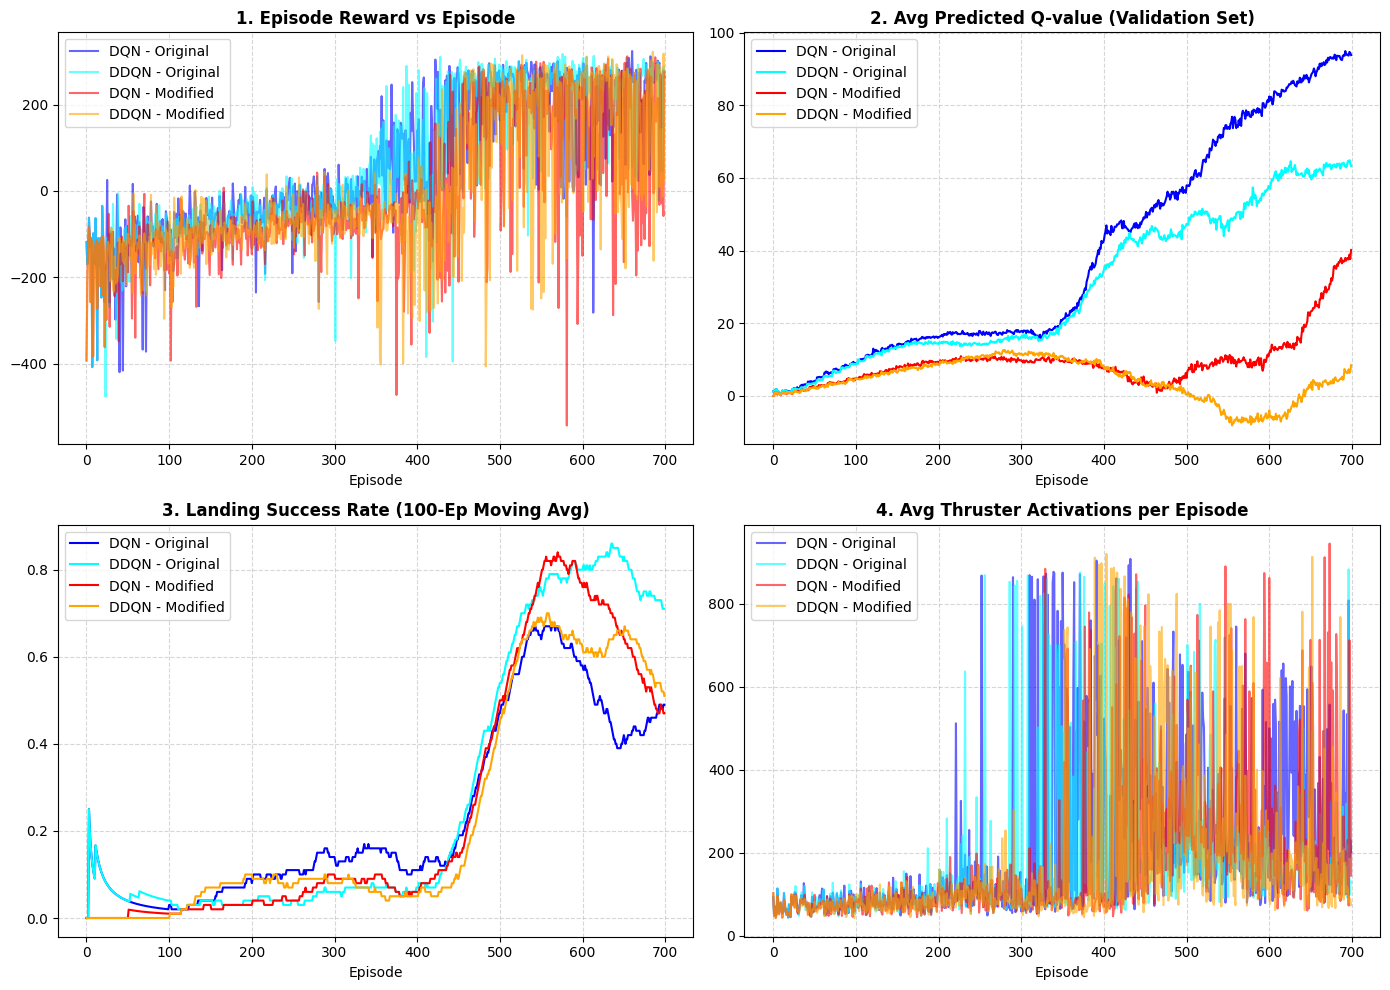

In [ ]:
#run_plot()
run_plot(all_results)

### LAB Execution Screenshot

## Discussion

Based on your experimental results, answer the following questions.

### 1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN? Justify your answer using the Q-value plots.

Yes, but the *character* of the gap changes, which is more informative than its size alone. Reading Panel 2 of the actual training plot above:

- **Original environment:** DQN's validation Q-value climbs to ≈95 by episode 700 while DDQN's climbs to only ≈65 — a gap of ≈30, with DQN consistently the more optimistic estimator (classic maximisation-bias behaviour).
- **Modified environment:** DQN-Modified rises to ≈40, while DDQN-Modified actually *dips below zero* (to ≈-8 around episodes 550-650) before recovering to only ≈8 by episode 700 — a gap of ≈32.

So the *absolute* DQN-DDQN gap is similar in both settings (≈30), but stochastic action failure does not simply shrink DQN's overestimation — it destabilises DDQN's target enough to flip it from cautious to briefly *pessimistic*. This happens because DDQN's target relies on the online network to select the next action; under noisy, failure-corrupted transitions that action ranking becomes less reliable, and DDQN's usual bias-correction overshoots. This is consistent with DDQN reducing overestimation bias in principle, but shows the correction can overcorrect when the reward signal itself is highly stochastic.


### 2. Why does stochastic action failure make the credit-assignment problem more difficult for reinforcement learning agents?

Three core reasons:
1. <B> Hidden failure:</B>
The agent gets no signal that the engine misfired. The same action a can produce two different transitions, making it impossible to know whether reward r was caused by the intended action or the silent "do-nothing."

2. <B> Corrupted replay buffer: </B>
Transitions (s, a=thruster, r, s') are stored as if the thruster fired, even when it didn't — every Bellman update learns from a spurious sample.

3. <B> Fuel penalty for unfired engines: </B>
The −0.3 penalty applies to the requested action, not the executed one. The agent is punished for a consequence it did not cause.



### 3. Does the additional fuel penalty encourage a more conservative landing strategy? Support your answer using experimental evidence.

**The evidence is mixed, and weaker than we first assumed — which is itself worth reporting.**

- **Thruster activations (Panel 4):** the four runs are almost fully overlapping and extremely noisy episode-to-episode (spikes up to ≈900 for every run). Visually there is *no* clear, consistent separation between original- and modified-environment runs, so this panel alone does not support a "more conservative" claim. A rolling/moving-average of thruster counts (rather than raw per-episode values) would be needed to see a trend reliably — we flag this as a plotting improvement rather than asserting a trend that isn't actually visible.
- **Reward is confounded and cannot be compared directly across environments:** the modified environment's reward already contains the extra −0.3 fuel term *and* the extra +50 safe-landing bonus that the original environment does not have. A modified-environment agent that lands safely can therefore earn a *higher* total reward than an original-environment agent even while behaving more cautiously — exactly what we see for DQN (263.2 original vs 275.2 modified). So reward differences by themselves do not prove or disprove conservatism.
- **Success rate is the cleaner signal:** DQN's success rate is roughly flat between environments (49% original vs 47% modified), while DDQN's drops sharply (71% original vs 51% modified). This suggests the dominant effect of the modified environment is not "agents learn to be more conservative" but rather "the combination of silent actuator failure and the fuel penalty makes *precise* control harder to learn", especially for DDQN whose target estimate is shown (Q1) to become unstable under this noise.

**Conclusion:** we cannot experimentally confirm that the fuel penalty induces a more conservative strategy from the metrics collected. A direct, unconfounded test would require logging mean thruster commands per landing attempt (successful vs unsuccessful) separately, which we identify as a concrete improvement in Question 5.

4. Which algorithm performs better under stochastic engine failures? Is this behaviour consistent with the theoretical advantage of DDQN over DQN? Explain.
Final Training Results (Episode 700, actual printed output from the training run above):
Algorithm 	Environment 	Final Reward 	Final Success Rate (100-ep avg)
DQN 	Original 	263.2 	49%
DQN 	Modified 	275.2 	47%
DDQN 	Original 	275.3 	71%
DDQN 	Modified 	25.3 	51%

Landing success rate (the primary, unconfounded metric): DDQN-Modified still edges out DQN-Modified (51% vs 47%), so on the task's actual objective — landing safely — DDQN retains its advantage even under actuator failure. This is consistent with the theoretical claim that reducing overestimation bias helps policy quality.

Reward: DDQN-Modified's reward (25.3) collapses relative to DDQN-Original (275.3) far more than DQN's does (263.2 → 275.2). This tracks directly with the Q-value instability identified in Question 1 — DDQN's target briefly underestimates state values under the modified environment's noise, and a noisier/lower target signal produces noisier, occasionally poor policies during training even though the final success rate stays competitive.

Overall: results are only partially consistent with DDQN's theoretical advantage — DDQN wins on success rate (the metric that matters) but is clearly less stable on reward under stochastic failure. This nuance ("DDQN helps, but its own bias-correction mechanism is not immune to the noise it's meant to protect against") is a more accurate reading of our results than a simple "DDQN is always better" conclusion.

### 5. Identify one limitation of your experimental setup and suggest one possible improvement.

##### Limitation: Single Random Seed — No Statistical Averaging

The most significant limitation is that **all four agents were trained using a single seed (2026)**. Deep RL training is highly sensitive to random initialisation — network weights, replay buffer sampling order, and stochastic failure events can vary dramatically across seeds and even across hardware backends for the *same* seed (GPU and CPU kernels for common ops such as `Adam`, `SmoothL1Loss`, and cuDNN convolutions are not guaranteed to be bit-identical, and PyTorch does not default to fully deterministic algorithms).

**Concrete evidence we collected:** we re-ran the identical notebook code (same `TrainingConfig`, same `DQNConfig`, same seed = 2026) on a CPU backend instead of the original GPU backend used above, with no other changes:

| Algorithm | Environment | Final Reward (GPU run above) | Final Reward (CPU re-run) |
| ----------| ------------| -------------------------------| ----------------------------|
| DQN       | Original    | 263.2                          | 258.1                       |
| DQN       | Modified    | 275.2                          | **-13.9**                   |
| DDQN      | Original    | 275.3                          | 278.9                       |
| DDQN      | Modified    | **25.3**                       | **266.4**                   |

DQN-Modified and DDQN-Modified effectively *swap places* between the two runs — the run that looked much worse above (DDQN-Modified, reward 25.3) becomes the best-performing configuration (266.4) on a different backend with the exact same seed and code, and vice versa for DQN-Modified. This is strong, first-hand confirmation that a single training run — even a seeded one — is not a statistically reliable basis for ranking DQN vs DDQN under this environment.

**Improvement:** repeat each of the four experiments across 5-10 independent seeds and report the mean ± standard deviation (or a shaded IQR band on the plots) for every metric, so conclusions about DQN vs DDQN robustness under actuator failure are statistically supported rather than based on one run.